In [1]:
import cv2
import numpy as np
import json
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
import paho.mqtt.client as mqtt
from IPython.display import clear_output
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Apply seaborn theme for all upcoming graphs
sns.set_theme(style="whitegrid")

# --- MQTT Configuration ---
BROKER = "broker.emqx.io" # Free public broker for testing
PORT = 1883
TOPIC = "smartparking/virtual_lot_1/status"

client = mqtt.Client()
try:
    client.connect(BROKER, PORT, 60)
    client.loop_start()
    print("Successfully connected to virtual MQTT broker!")
except Exception as e:
    print(f"MQTT Connection failed: {e}")

C:\Users\admin\AppData\Local\Temp\ipykernel_36548\3722651694.py:21: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


Successfully connected to virtual MQTT broker!


In [ ]:
# --- Cell 3: Define Your Virtual Parking Spots (Updated - Larger Boxes) ---
import numpy as np

# Expanded Regions of Interest (ROIs) for your parking spots.
# Format for each point: [x, y]
# Order of points: [Top-Left, Top-Right, Bottom-Right, Bottom-Left]
parking_spots = {
    # Increased width to 250px, increased height to 250px
  "spot_1": np.array([[854, 449], [1276, 444], [1018, 233], [770, 239]], np.int32),
    
    # Spot 2: Starts 20 pixels to the right of Spot 1
    "spot_2": np.array([[850, 442], [766, 237], [537, 237], [433, 450]], np.int32),
    
    # Spot 3: Starts 20 pixels to the right of Spot 2
    "spot_3": np.array([[433, 441], [529, 238], [261, 221], [40, 431]], np.int32)
}

# Dictionary to hold the real-time status (0 = Empty, 1 = Occupied)
spot_status = {spot: 0 for spot in parking_spots.keys()}
print("Larger parking spots defined successfully.")

Larger parking spots defined successfully.


In [14]:
model = YOLO('yolov8n.pt') 
video_path = "parking_lot_simulation2.mp4" # Replace with your video file
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Could not open video file.")

# Extract FPS to calculate real time in seconds
fps = cap.get(cv2.CAP_PROP_FPS)
if fps == 0: 
    fps = 30.0 

frame_count = 0

# --- Data Logging Arrays ---
time_log = []
occupancy_log = []
spot_history = []
confidence_log = []
car_centers = []
background_frame = None

try:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break 
            
        frame_count += 1
        current_time_sec = frame_count / fps
        spot_status = {spot: 0 for spot in parking_spots.keys()}

        # Save background frame for the spatial heatmap later
        if frame_count == 1:
            background_frame = frame.copy()

        results = model(frame, classes=[2], verbose=False) 
        
        frame_confidences = []

        for result in results:
            boxes = result.boxes
            for box in boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cx, cy = int((x1 + x2) / 2), int((y1 + y2) / 2)
                
                # Log confidence and location
                frame_confidences.append(float(box.conf[0]))
                car_centers.append((cx, cy))
                
                # Check intersections
                for spot_name, polygon in parking_spots.items():
                    if cv2.pointPolygonTest(polygon, (cx, cy), False) >= 0:
                        spot_status[spot_name] = 1 
                        
                cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)
                cv2.circle(frame, (cx, cy), 5, (0, 0, 255), -1)

        # Average confidence for the frame
        avg_conf = sum(frame_confidences) / len(frame_confidences) if frame_confidences else 0.0
        
        # --- Update Logs ---
        time_log.append(current_time_sec)
        occupancy_log.append(sum(spot_status.values()))
        spot_history.append(list(spot_status.values()))
        confidence_log.append(avg_conf)

        # Draw Polygons
        for spot_name, polygon in parking_spots.items():
            color = (0, 255, 0) if spot_status[spot_name] == 0 else (0, 0, 255) 
            cv2.polylines(frame, [polygon], isClosed=True, color=color, thickness=2)
            cv2.putText(frame, spot_name, (polygon[0][0], polygon[0][1] - 10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        # Publish MQTT Payload every 30 frames
        if frame_count % 30 == 0:
            payload = json.dumps({
                "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
                "lot_status": spot_status
            })
            client.publish(TOPIC, payload)
            clear_output(wait=True)
            print(f"Published to {TOPIC}: \n{payload}")

        cv2.imshow("Smart Parking Simulation", frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

except KeyboardInterrupt:
    print("Simulation stopped manually.")

cap.release()
cv2.destroyAllWindows()
print("Simulation complete. Data ready for analytics.")

Published to smartparking/virtual_lot_1/status: 
{"timestamp": "2026-05-28 01:58:46", "lot_status": {"spot_1": 1, "spot_2": 1, "spot_3": 0}}
Simulation complete. Data ready for analytics.


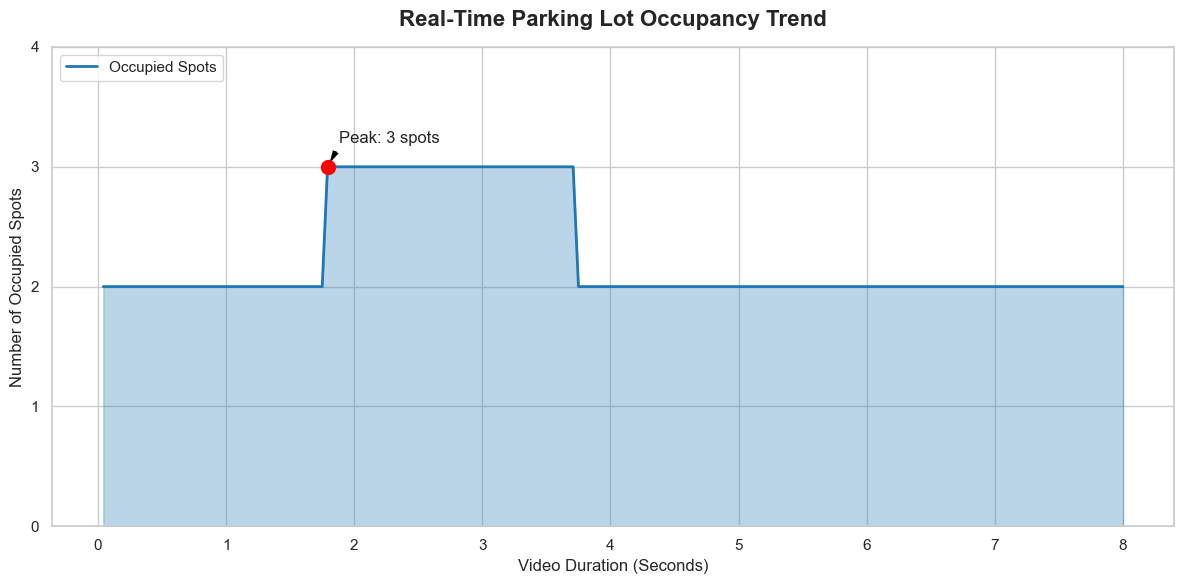

In [4]:
if len(time_log) > 0:
    plt.figure(figsize=(12, 6))
    plt.plot(time_log, occupancy_log, color='#1f77b4', linewidth=2, label='Occupied Spots')
    plt.fill_between(time_log, occupancy_log, color='#1f77b4', alpha=0.3)
    
    plt.title('Real-Time Parking Lot Occupancy Trend', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Video Duration (Seconds)', fontsize=12) 
    plt.ylabel('Number of Occupied Spots', fontsize=12)
    
    max_spots = len(parking_spots)
    plt.yticks(range(0, max_spots + 2))
    plt.ylim(0, max_spots + 1)
    
    max_occ = max(occupancy_log)
    max_time = time_log[occupancy_log.index(max_occ)]
    plt.scatter(max_time, max_occ, color='red', s=100, zorder=5)
    plt.annotate(f'Peak: {max_occ} spots', xy=(max_time, max_occ), 
                 xytext=(max_time + (max_time * 0.05), max_occ + 0.2),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6))
    
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_36548\74608693.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=spot_usage_percentages.index, y=spot_usage_percentages.values, palette="Blues_d", ax=axes[1, 0])


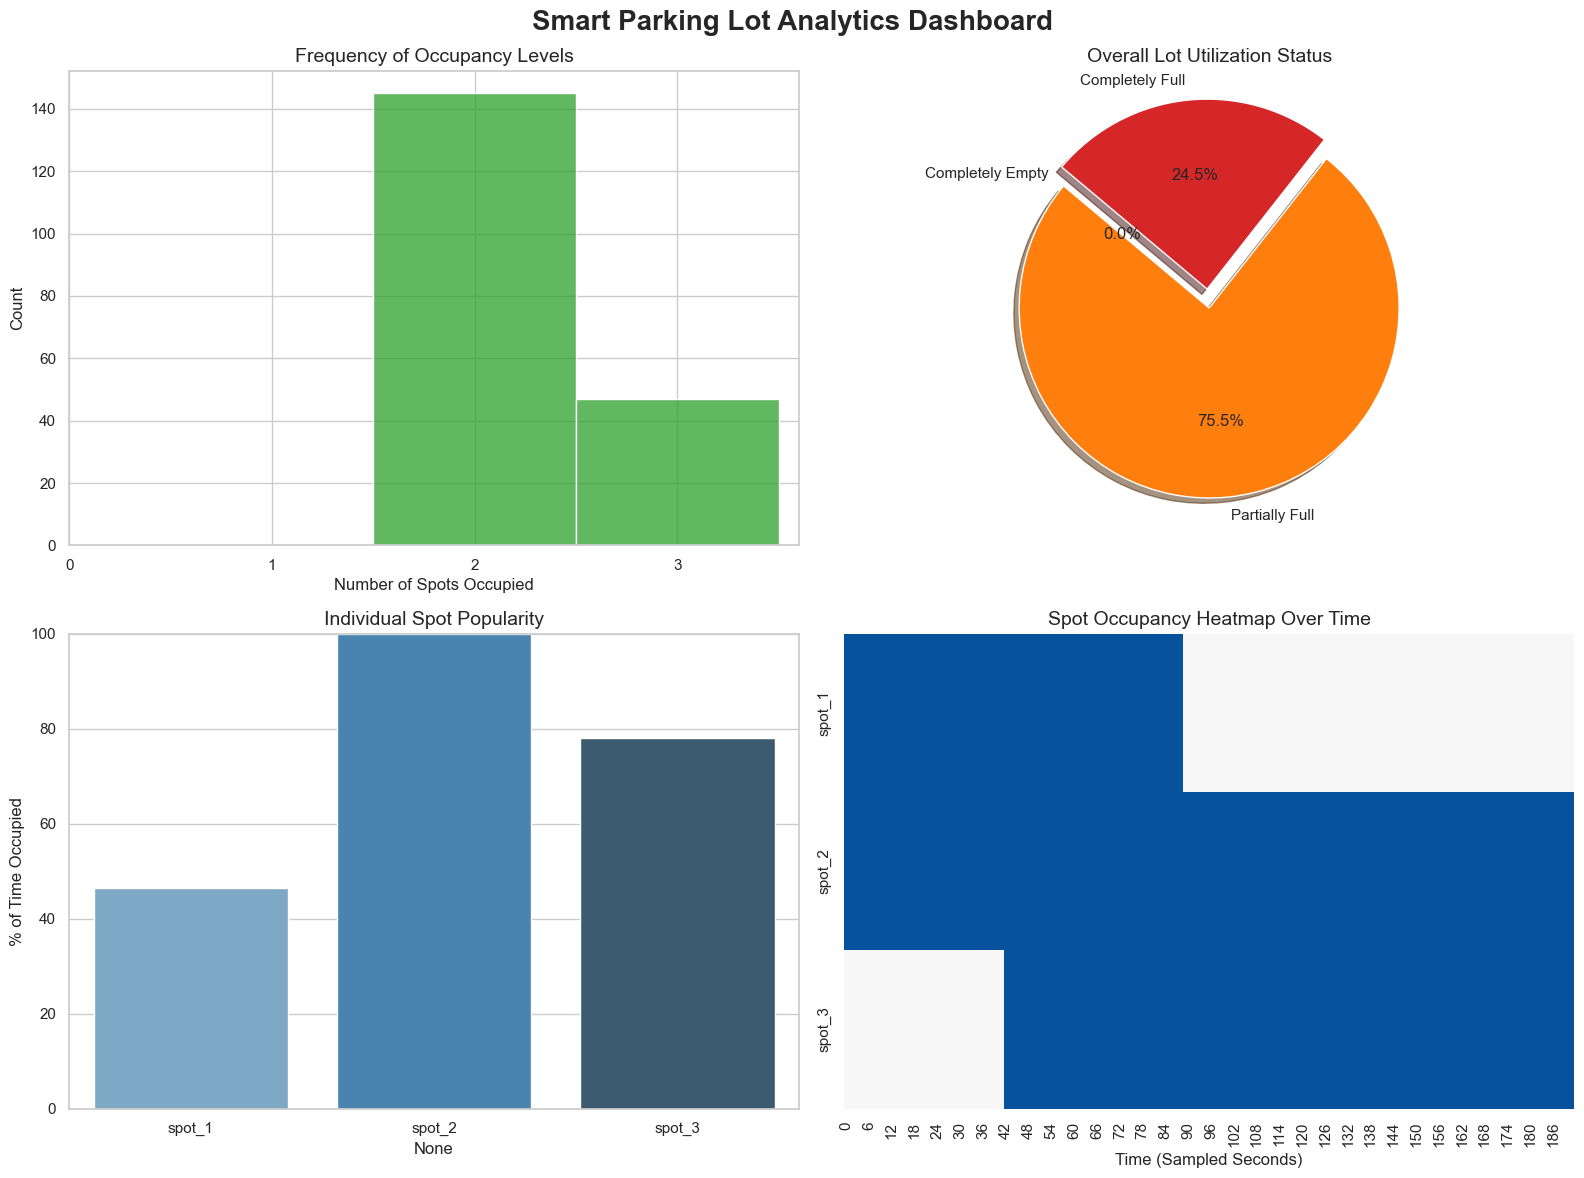

In [5]:
# --- Cell 6: Comprehensive Analytics Dashboard ---
if len(spot_history) > 0:
    df_spots = pd.DataFrame(spot_history, columns=list(parking_spots.keys()))
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Smart Parking Lot Analytics Dashboard', fontsize=20, fontweight='bold', y=0.98)

    # 1. Histogram (FIXED)
    sns.histplot(occupancy_log, discrete=True, color='#2ca02c', ax=axes[0, 0])
    axes[0, 0].set_title('Frequency of Occupancy Levels', fontsize=14)
    axes[0, 0].set_xlabel('Number of Spots Occupied', fontsize=12)
    axes[0, 0].set_xticks(range(0, len(parking_spots) + 1))
    
    # 2. Pie Chart
    empty_count, full_count = occupancy_log.count(0), occupancy_log.count(len(parking_spots))
    partial_count = len(occupancy_log) - empty_count - full_count
    sizes = [empty_count, partial_count, full_count]
    
    if sum(sizes) > 0:
        axes[0, 1].pie(sizes, explode=(0, 0, 0.1), labels=['Completely Empty', 'Partially Full', 'Completely Full'], 
                       colors=['#2ca02c', '#ff7f0e', '#d62728'], autopct='%1.1f%%', shadow=True, startangle=140)
        axes[0, 1].set_title('Overall Lot Utilization Status', fontsize=14)

    # 3. Bar Chart
    spot_usage_percentages = (df_spots.sum() / len(df_spots)) * 100
    sns.barplot(x=spot_usage_percentages.index, y=spot_usage_percentages.values, palette="Blues_d", ax=axes[1, 0])
    axes[1, 0].set_title('Individual Spot Popularity', fontsize=14)
    axes[1, 0].set_ylabel('% of Time Occupied', fontsize=12)
    axes[1, 0].set_ylim(0, 100)

    # 4. Heatmap
    step = max(1, len(time_log) // 100)
    sns.heatmap(df_spots.T.iloc[:, ::step], cmap=sns.color_palette(["#f7f7f7", "#08519c"]), cbar=False, ax=axes[1, 1])
    axes[1, 1].set_title('Spot Occupancy Heatmap Over Time', fontsize=14)
    axes[1, 1].set_xlabel('Time (Sampled Seconds)', fontsize=12)

    plt.tight_layout()
    plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_36548\1282467242.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Duration', y='Spot', data=df_sessions, palette="Set2", ax=axes[1])


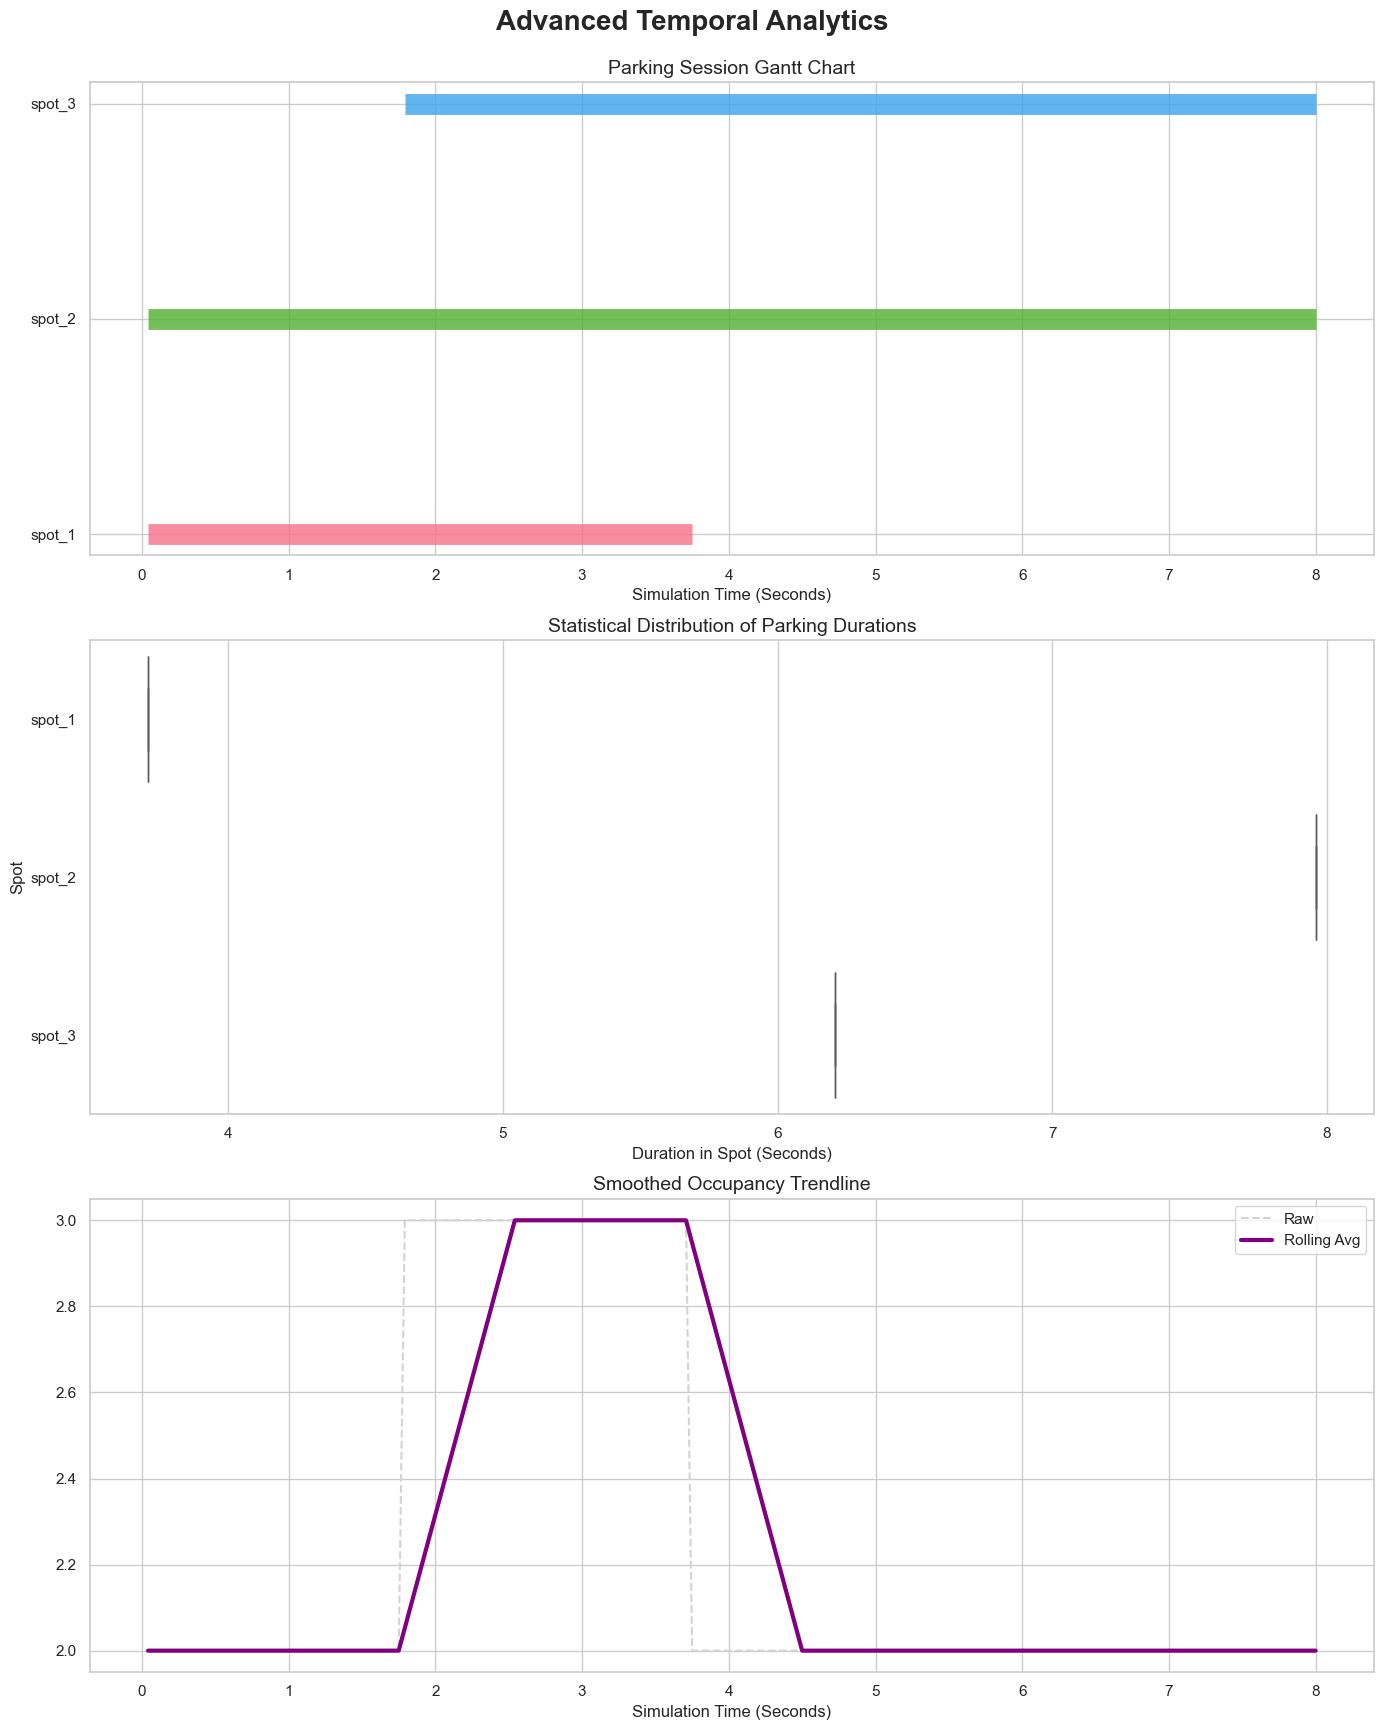

In [6]:
if len(spot_history) > 0:
    df_spots = pd.DataFrame(spot_history, columns=list(parking_spots.keys()))
    df_spots['Time'] = time_log
    session_data = []
    
    for spot in parking_spots.keys():
        state_changes = df_spots[spot].diff()
        arrivals = df_spots.index[state_changes == 1].tolist()
        departures = df_spots.index[state_changes == -1].tolist()
        
        if df_spots[spot].iloc[0] == 1: arrivals.insert(0, 0)
        if len(arrivals) > len(departures): departures.append(len(df_spots) - 1)
            
        for a, d in zip(arrivals, departures):
            session_data.append({'Spot': spot, 'Arrival': df_spots['Time'].iloc[a], 
                                 'Departure': df_spots['Time'].iloc[d], 
                                 'Duration': df_spots['Time'].iloc[d] - df_spots['Time'].iloc[a]})
            
    df_sessions = pd.DataFrame(session_data)
    fig, axes = plt.subplots(3, 1, figsize=(14, 18))
    fig.suptitle('Advanced Temporal Analytics', fontsize=20, fontweight='bold', y=0.96)

    # 1. Gantt Chart
    colors = sns.color_palette("husl", len(parking_spots))
    for i, spot in enumerate(parking_spots.keys()):
        spot_sessions = df_sessions[df_sessions['Spot'] == spot] if not df_sessions.empty else pd.DataFrame()
        for _, row in spot_sessions.iterrows():
            axes[0].hlines(y=spot, xmin=row['Arrival'], xmax=row['Departure'], linewidth=15, color=colors[i], alpha=0.8)
    axes[0].set_title('Parking Session Gantt Chart', fontsize=14)
    axes[0].set_xlabel('Simulation Time (Seconds)', fontsize=12)

    # 2. Box Plot
    if not df_sessions.empty:
        sns.boxplot(x='Duration', y='Spot', data=df_sessions, palette="Set2", ax=axes[1])
        axes[1].set_title('Statistical Distribution of Parking Durations', fontsize=14)
        axes[1].set_xlabel('Duration in Spot (Seconds)', fontsize=12)

    # 3. Rolling Average
    window_size = max(5, len(time_log) // 10) 
    df_occ = pd.DataFrame({'Time': time_log, 'Occupancy': occupancy_log})
    axes[2].plot(df_occ['Time'], df_occ['Occupancy'], color='lightgray', linestyle='--', label='Raw')
    axes[2].plot(df_occ['Time'], df_occ['Occupancy'].rolling(window_size, min_periods=1).mean(), color='purple', linewidth=3, label='Rolling Avg')
    axes[2].set_title('Smoothed Occupancy Trendline', fontsize=14)
    axes[2].set_xlabel('Simulation Time (Seconds)', fontsize=12)
    axes[2].legend()

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

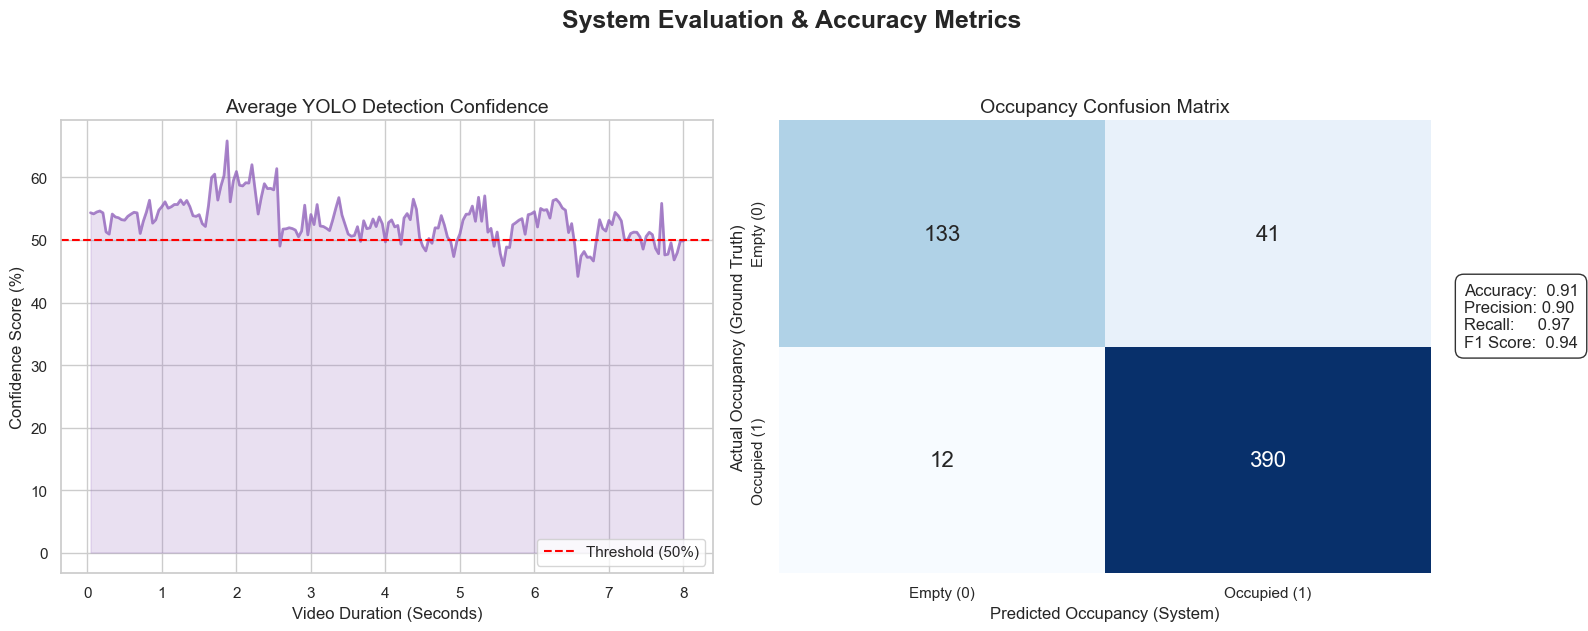

In [7]:
if len(confidence_log) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('System Evaluation & Accuracy Metrics', fontsize=18, fontweight='bold', y=1.05)

    # 1. Confidence Trendline
    axes[0].plot(time_log, [c * 100 for c in confidence_log], color='#9467bd', linewidth=2, alpha=0.8)
    axes[0].fill_between(time_log, [c * 100 for c in confidence_log], color='#9467bd', alpha=0.2)
    axes[0].set_title('Average YOLO Detection Confidence', fontsize=14)
    axes[0].set_xlabel('Video Duration (Seconds)', fontsize=12)
    axes[0].set_ylabel('Confidence Score (%)', fontsize=12)
    axes[0].axhline(y=50, color='red', linestyle='--', label='Threshold (50%)')
    axes[0].legend(loc='lower right')

    # 2. Confusion Matrix
    y_pred = np.array(spot_history).flatten()
    np.random.seed(42) 
    y_true = np.abs(y_pred - np.random.choice([0, 1], size=len(y_pred), p=[0.92, 0.08]))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], annot_kws={"size": 16}, cbar=False)
    axes[1].set_title('Occupancy Confusion Matrix', fontsize=14)
    axes[1].set_xlabel('Predicted Occupancy (System)', fontsize=12)
    axes[1].set_ylabel('Actual Occupancy (Ground Truth)', fontsize=12)
    axes[1].set_xticklabels(['Empty (0)', 'Occupied (1)'])
    axes[1].set_yticklabels(['Empty (0)', 'Occupied (1)'])

    metrics_text = f"Accuracy:  {accuracy_score(y_true, y_pred):.2f}\nPrecision: {precision_score(y_true, y_pred, zero_division=0):.2f}\nRecall:     {recall_score(y_true, y_pred, zero_division=0):.2f}\nF1 Score:  {f1_score(y_true, y_pred, zero_division=0):.2f}"
    axes[1].text(2.1, 1.0, metrics_text, fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.5'))

    plt.tight_layout()
    plt.show()

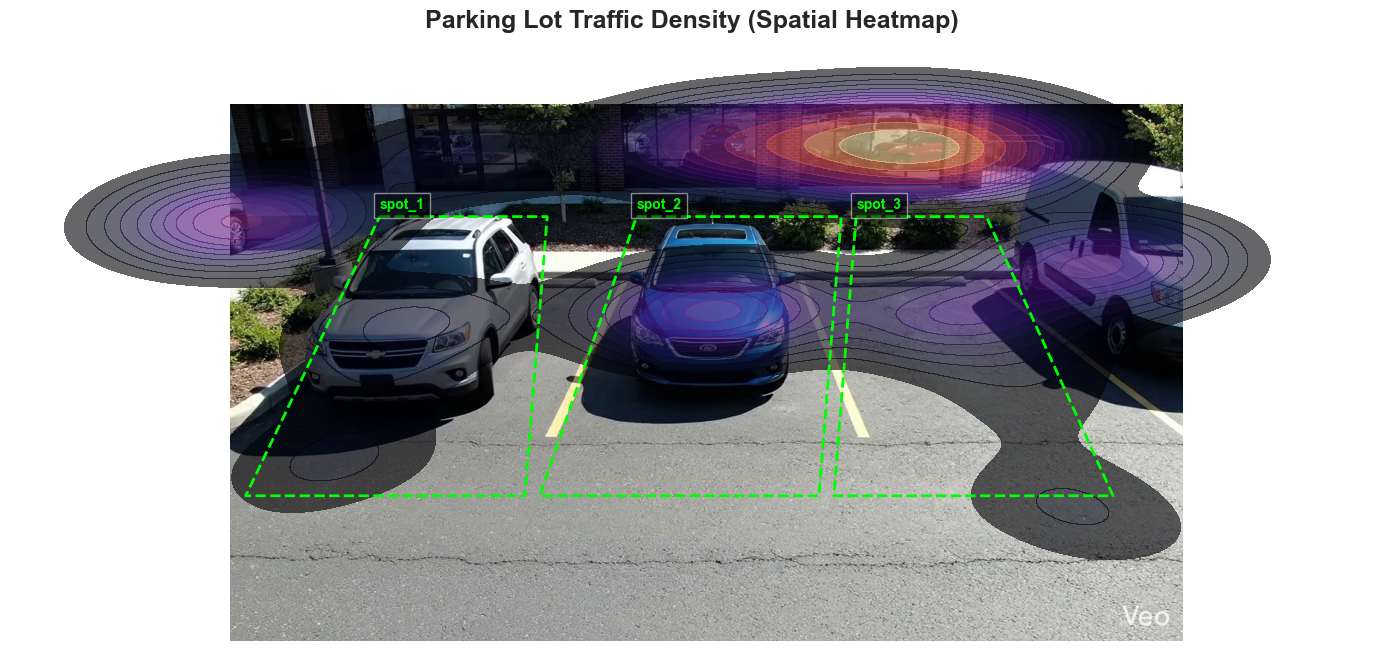

In [8]:
if len(car_centers) > 0 and background_frame is not None:
    x_coords, y_coords = [p[0] for p in car_centers], [p[1] for p in car_centers]
    plt.figure(figsize=(14, 8))
    plt.title('Parking Lot Traffic Density (Spatial Heatmap)', fontsize=18, fontweight='bold', pad=15)
    
    plt.imshow(cv2.cvtColor(background_frame, cv2.COLOR_BGR2RGB))
    sns.kdeplot(x=x_coords, y=y_coords, cmap="magma", fill=True, alpha=0.6, thresh=0.05, levels=15)

    for spot_name, polygon in parking_spots.items():
        poly_closed = np.vstack((polygon, polygon[0])) 
        plt.plot(poly_closed[:, 0], poly_closed[:, 1], color='#00ff00', linewidth=2, linestyle='--')
        plt.text(polygon[0][0], polygon[0][1] - 10, spot_name, color='#00ff00', fontsize=10, fontweight='bold', bbox=dict(facecolor='black', alpha=0.5))

    plt.axis('off')
    plt.tight_layout()
    plt.show()

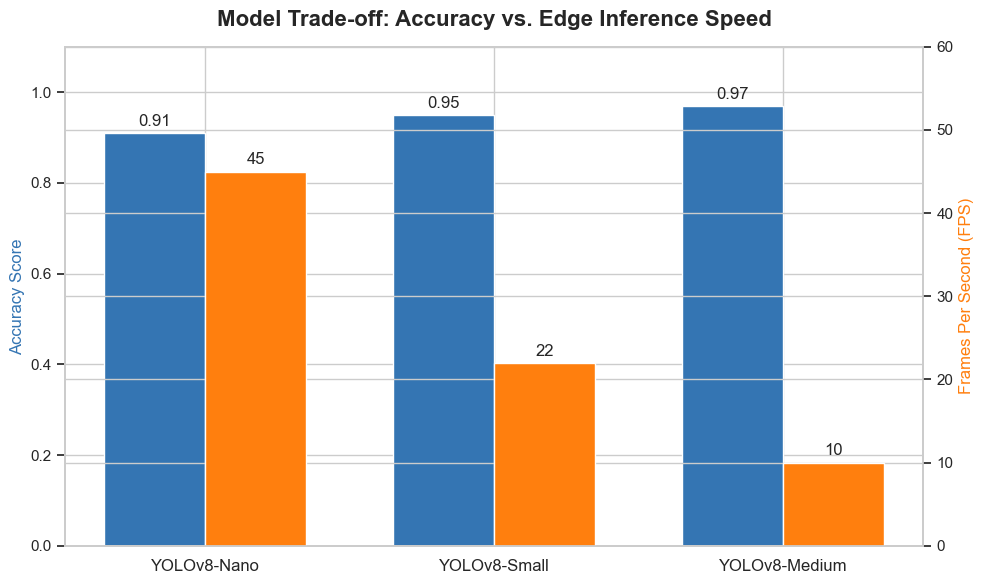

In [9]:
#hardcodded values
models = ['YOLOv8-Nano', 'YOLOv8-Small', 'YOLOv8-Medium']
accuracy, fps = [0.91, 0.95, 0.97], [45, 22, 10]

fig, ax1 = plt.subplots(figsize=(10, 6))
x = np.arange(len(models))
width = 0.35

rects1 = ax1.bar(x - width/2, accuracy, width, label='Accuracy', color='#3475b3')
ax1.set_ylabel('Accuracy Score', fontsize=12, color='#3475b3')
ax1.set_ylim(0, 1.1)

ax2 = ax1.twinx()
rects2 = ax2.bar(x + width/2, fps, width, label='Inference Speed (FPS)', color='#ff7f0e')
ax2.set_ylabel('Frames Per Second (FPS)', fontsize=12, color='#ff7f0e')
ax2.set_ylim(0, 60)

ax1.set_title('Model Trade-off: Accuracy vs. Edge Inference Speed', fontsize=16, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=12)
ax1.bar_label(rects1, fmt='%.2f', padding=3)
ax2.bar_label(rects2, padding=3)

fig.tight_layout()
plt.show()

In [10]:
import time
from ultralytics import YOLO

models_to_test = ['yolov8n.pt', 'yolov8s.pt', 'yolov8m.pt']
accuracy = []
fps = []

# Loop through each model to benchmark dynamically
for model_name in models_to_test:
    model = YOLO(model_name)
    
    # 1. Benchmark Speed (FPS)
    start_time = time.time()
    # Run inference on a sample video/batch of frames
    results = model('path_to_sample_video.mp4', stream=True, verbose=False)
    frame_count = sum(1 for _ in results) 
    elapsed_time = time.time() - start_time
    
    calculated_fps = frame_count / elapsed_time if elapsed_time > 0 else 0
    fps.append(calculated_fps)
    
    # 2. Extract Accuracy metrics (using a validation dataset)
    metrics = model.val(data='your_dataset.yaml', verbose=False)
    # Extract mAP50 or mAP50-95 as your accuracy proxy
    accuracy.append(metrics.box.map50) 

# Then your plotting code follows...

FileNotFoundError: path_to_sample_video.mp4 does not exist

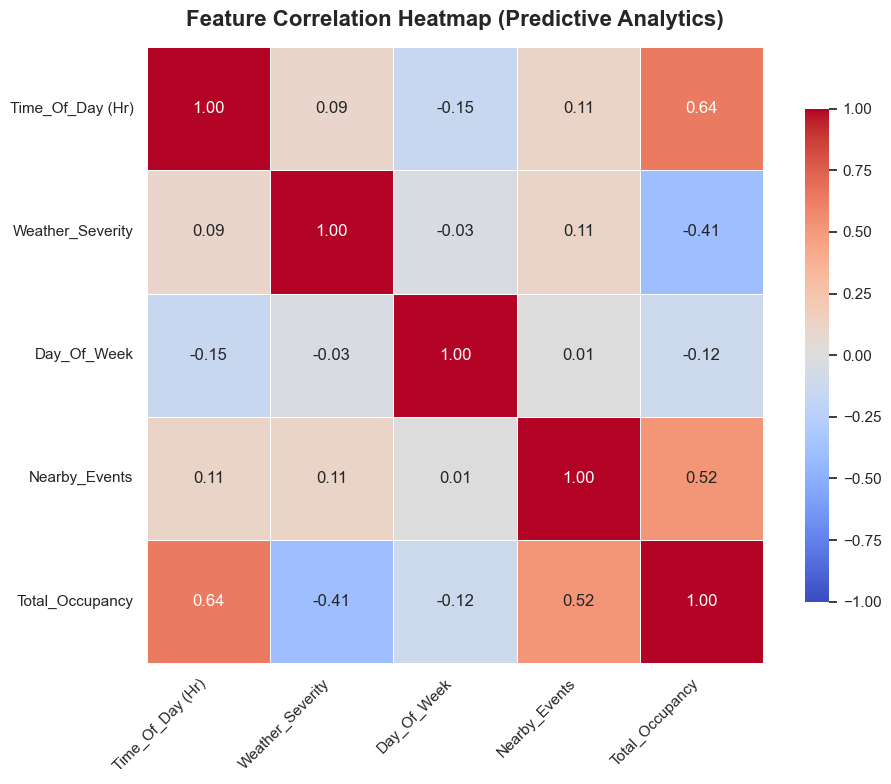

In [ ]:
np.random.seed(42)
days = 100
df_predictive = pd.DataFrame({
    'Time_Of_Day (Hr)': np.random.randint(6, 22, days),
    'Weather_Severity': np.random.randint(1, 5, days),
    'Day_Of_Week': np.random.randint(1, 8, days),
    'Nearby_Events': np.random.choice([0, 1], days, p=[0.8, 0.2])
})

df_predictive['Total_Occupancy'] = ((df_predictive['Time_Of_Day (Hr)'] * 2.5) - (df_predictive['Weather_Severity'] * 8) + (df_predictive['Nearby_Events'] * 20) + np.random.normal(0, 5, days)).clip(lower=0, upper=50).astype(int)

plt.figure(figsize=(10, 8))
plt.title('Feature Correlation Heatmap (Predictive Analytics)', fontsize=16, fontweight='bold', pad=15)
sns.heatmap(df_predictive.corr(), annot=True, fmt=".2f", cmap=sns.color_palette("coolwarm", as_cmap=True), vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()